# **Aplica mascaramento de nuvens e calcula o NDVI para o satélite Landsat-9**



- Exemplo retirado de: https://www.youtube.com/watch?v=LI5xfTzd_-E
- Dados utilizados: https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LC09_C02_T1_L2#bands


# Instalando Xee e inicializando GEE

Se você tiver uma conta do Earth Engine você poderá encontrar a sua ID de um projeto do GEE acessando https://code.earthengine.google.com/ com sua conta google, e depois verificando do lado superior direito do Code Editor o nome da sua ID.

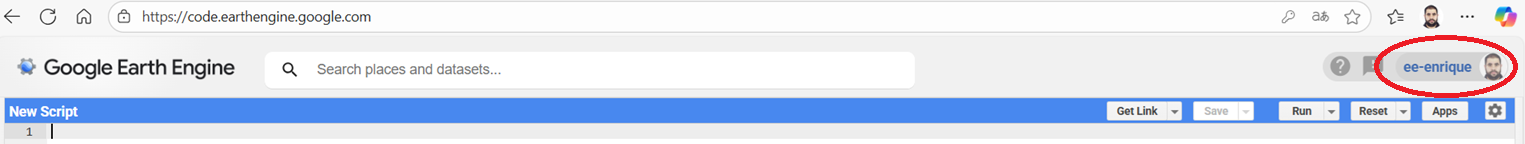

Insira a sua ID no campo `geemap.ee_initialize(project='SUA ID')`.

In [1]:
# instalando Xee
!pip install -q xee

# importa bibliotecas
import ee
import geemap
import xee
import xarray as xr

# inicializando pelo GEE
geemap.ee_initialize(project='ee-enrique', opt_url='https://earthengine-highvolume.googleapis.com')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.5 MB/s eta 0:00:00


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_7TDKVSyKvBdmMqW?ref=4i2o6


# Selecionando uma região

In [2]:
Map = geemap.Map(basemap = 'SATELLITE')
Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

Selecione um polígono na imagem interativa acima

In [3]:
#  estrai as coordenadas da região selecionada
roi = Map.draw_last_feature.geometry()

In [4]:
# mostra as coordenadas
roi

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "Feature.geometry",
    "arguments": {
      "feature": {
        "functionInvocationValue": {
          "functionName": "Feature",
          "arguments": {
            "geometry": {
              "functionInvocationValue": {
                "functionName": "GeometryConstructors.Polygon",
                "arguments": {
                  "coordinates": {
                    "constantValue": [
                      [
                        [
                          -48.233414,
                          -23.05304
                        ],
                        [
                          -48.182945,
                          -23.053198
                        ],
                        [
                          -48.189297,
                          -23.085891
                        ],
                        [
                          -48.237019,
                          -23.085891
                        ],
                        [
                          -48.233414,
                          -23.05304
                        ]
                      ]
                    ]
                  },
                  "geodesic": {
                    "constantValue": false
                  }
                }
              }
            }
          }
        }
      }
    }
  }
})

# Carregando os dados, aplicando o mascaramento de nuvens e calculando o NDVI

- Dados utilizados:  https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LC09_C02_T1_L2#bands


- São imagens a cada 16 dias do satélite Landasat-9.

O NDVI é calculado através da seguinte equação:

NDVI = (R0.8 - R0.6) / (R0.8 + R0.6). Em que: R0.8 é a banda do NIR e R0.6 é a banda do vermelho.


Aplicando para as bandas do Landsat-9 temos que:


NDVI = (B8 - B4) / (B8 + B4)

 - SR_B5 = 0.851-0.879 μm - NIR
 - SR_B4 = 0.636-0.673 μm - Vermelho

In [5]:
# carregando os dados
landsat_9 = ee.ImageCollection("LANDSAT/LC09/C02/T1_L2") \
         .filterDate('2024', '2025') \
         .filterBounds(roi)
landsat_9

Na função `cloud_mask(img)` a linha `cirrus = qa.bitwiseAnd(2 << 1).neq(0)` identifica pixels que contêm nuvens cirrus na banda de qualidade (QA) da imagem.

---

Explicação passo a passo:

---

1. `2 << 1` (Deslocamento de bits)
 - 2 em binário: `0010`
 - `<< 1` desloca 1 bit para a esquerda: `0010` → `0100`
 - Resultado: `0100` em binário (que é o número 4)

---

2. `bitwiseAnd()` (Operação AND bit a bit)
 - Aplica AND entre o valor do pixel QA e a máscara `0100`
 - Se o bit na posição 2 estiver ligado (valor 1), o resultado será diferente de zero

---

3. `.neq(0)` (Comparação)
 - Retorna true para pixels que são nuvens cirrus, `false` para outros
---

In [6]:
# criando uma função que aplica o mascaramento de nuvens e calcula o NDVI
def cloud_mask(img):

    # aplica máscara de nuvens
    qa = img.select('QA_PIXEL')

    dilated = qa.bitwiseAnd(1 << 1).neq(0)
    cirrus = qa.bitwiseAnd(2 << 1).neq(0)
    cloud = qa.bitwiseAnd(3 << 1).neq(0)
    shadow = qa.bitwiseAnd(4 << 1).neq(0)

    mask = dilated.Or(cirrus).Or(cloud).Or(shadow)

    ms = img.select('SR_B.*').multiply(2.75e-05).add(-0.2)

    # calculando NDVI
    ndvi = ms.normalizedDifference(['SR_B5','SR_B4']).rename('ndvi')

    return ndvi.updateMask(mask.Not()).copyProperties(img, ['system:time_start'])

In [7]:
# carregando os dados com a aplicação da máscara de nuvens
landsat_9 = ee.ImageCollection("LANDSAT/LC09/C02/T1_L2") \
         .filterDate('2024', '2025') \
         .filterBounds(roi) \
         .map(cloud_mask)
landsat_9

Propriedades da imagem antes de aplicar a máscara de nuvens e calcular o NDVI. Repare que temos todas as bandas da imagem.

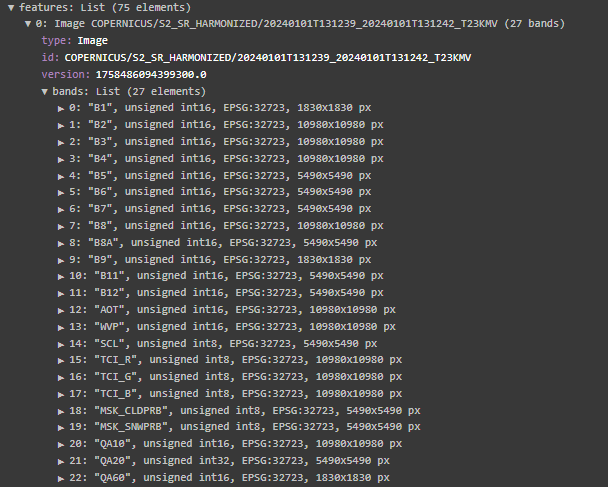

Repare que agora a banda dos dados tem apenas as informações da variável NDVI.

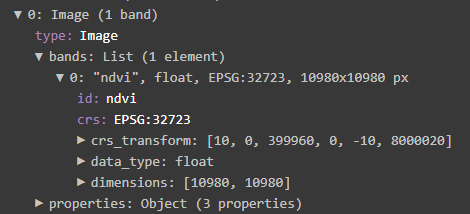

# Transformando as imagens para o formato do dataset do xarray

O atributo escala é a resolução espacial em graus. As bandas SR_B4 e SR_B5 do Landasat-9 tem 30 m de resolução espacial. Em km corresponde a 0.03 km. Para transformar de km para graus dividimos por 100, ou seja, 0.03/100 = 0.0003 graus. Porém, vamos usar uma resolução de 100m, ou seja 0.001 graus.





In [17]:
# transformando os dados para dataset do xarray. Resolução de 100 m (scale = 0.001)
ds = xr.open_dataset(landsat_9,
                     engine = 'ee',
                     crs = 'EPSG:4326',
                     geometry = roi,
                     scale = 0.001)

In [18]:
# mostrando os dados
ds

<xarray.Dataset> Size: 11kB
Dimensions:  (time: 48, lon: 9, lat: 6)
Coordinates:
  * time     (time) datetime64[ns] 384B 2024-02-12T13:04:38.455000 ... 2024-1...
  * lon      (lon) float64 72B -47.35 -47.35 -47.34 ... -47.34 -47.34 -47.34
  * lat      (lat) float64 48B -22.55 -22.55 -22.55 -22.55 -22.55 -22.55
Data variables:
    ndvi     (time, lon, lat) float32 10kB ...
Attributes:
    crs:      EPSG:4326

In [19]:
# essa multiplicação por "1" aumenta a velocidade de processamento. Não muda nada nos dados
ds = ds.sortby('time') * 1

In [20]:
# mostrando os dados
ds

<xarray.Dataset> Size: 11kB
Dimensions:  (time: 48, lon: 9, lat: 6)
Coordinates:
  * time     (time) datetime64[ns] 384B 2024-01-02T13:10:24.615000 ... 2024-1...
  * lon      (lon) float64 72B -47.35 -47.35 -47.34 ... -47.34 -47.34 -47.34
  * lat      (lat) float64 48B -22.55 -22.55 -22.55 -22.55 -22.55 -22.55
Data variables:
    ndvi     (time, lon, lat) float32 10kB nan nan 0.5914 0.4261 ... nan nan nan
Attributes:
    crs:      EPSG:4326

# Plotando gráficos



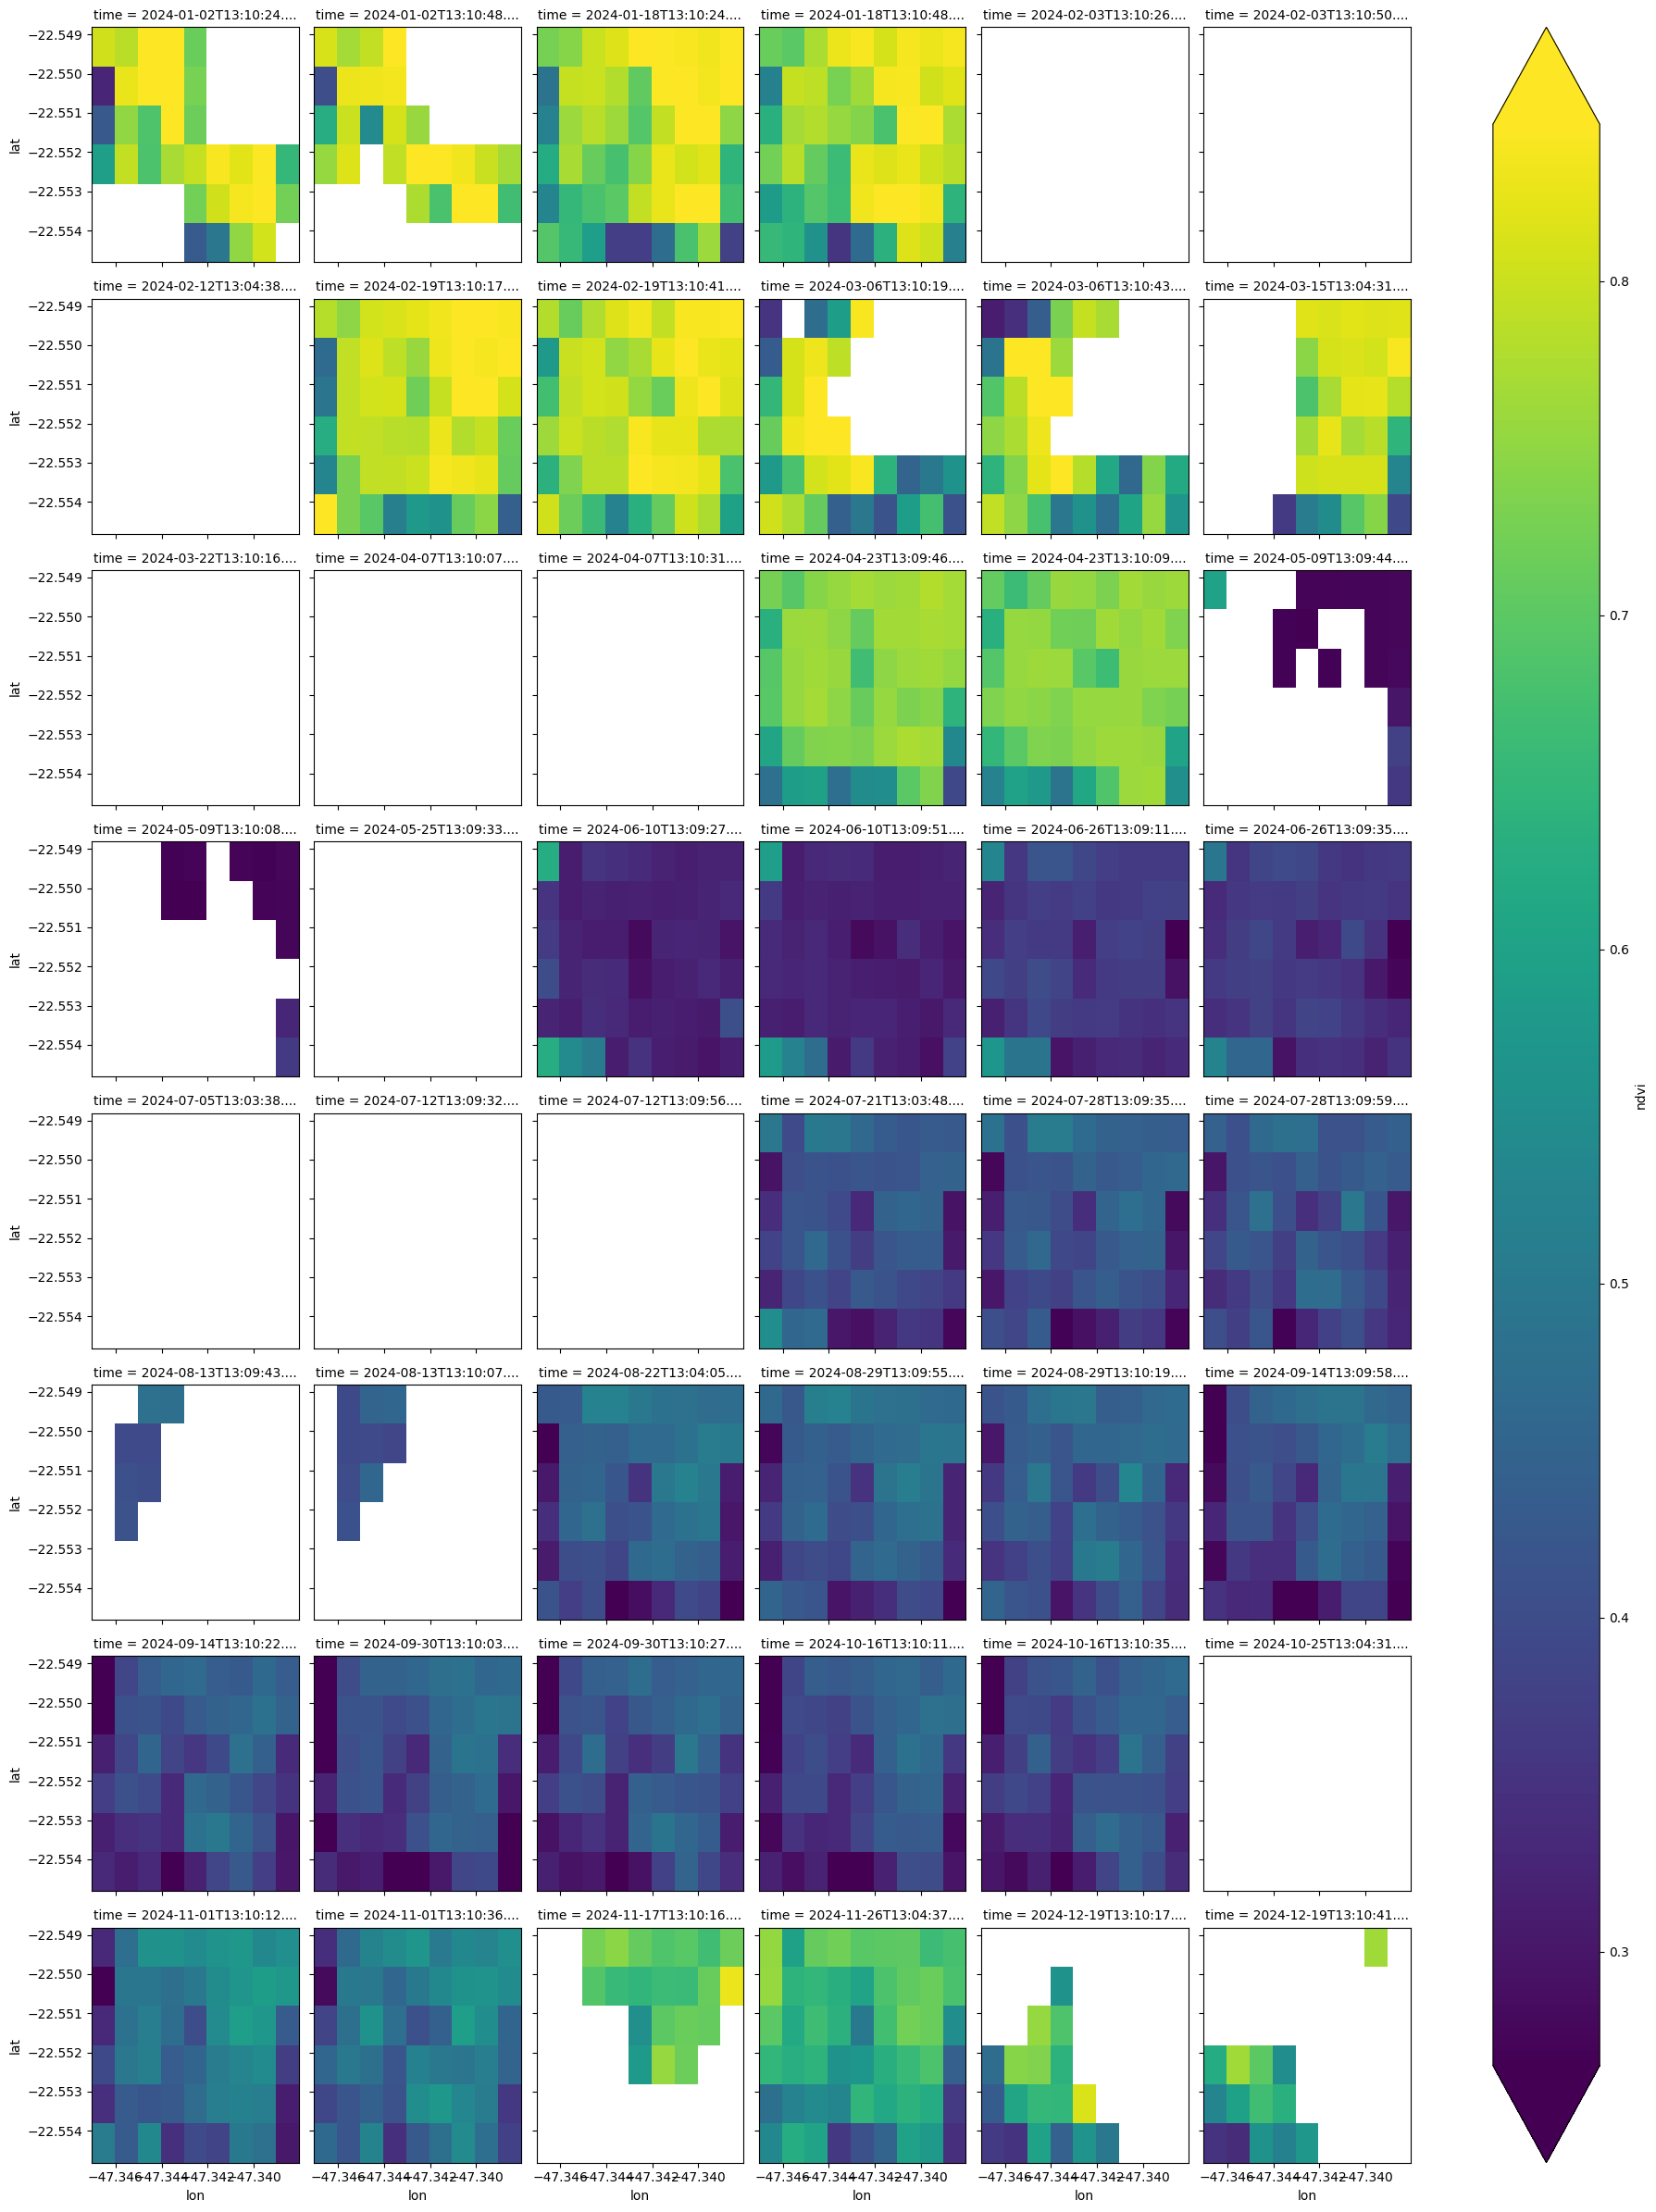

In [23]:
# gráfico. Plotando todas as imagens da coleção. Lembre-se são imagens do Landsat-9 de 2024, a cada 16 dias.
ds.ndvi.plot(x = 'lon',
             y = 'lat',
             col = 'time',
             col_wrap = 6,
             robust = True)

Os espaços em branco nas imagens, são os locais que ocorreram nuvens.

In [24]:
# aplicando a média móvel de 7 tempos
ds_rol = ds.rolling(time = 7, min_periods = 1, center = True).mean('time')

In [25]:
# mostrando os dados
ds_rol

<xarray.Dataset> Size: 11kB
Dimensions:  (time: 48, lon: 9, lat: 6)
Coordinates:
  * time     (time) datetime64[ns] 384B 2024-01-02T13:10:24.615000 ... 2024-1...
  * lon      (lon) float64 72B -47.35 -47.35 -47.34 ... -47.34 -47.34 -47.34
  * lat      (lat) float64 48B -22.55 -22.55 -22.55 -22.55 -22.55 -22.55
Data variables:
    ndvi     (time, lon, lat) float32 10kB 0.6726 0.5572 ... 0.7544 0.6962
Attributes:
    crs:      EPSG:4326

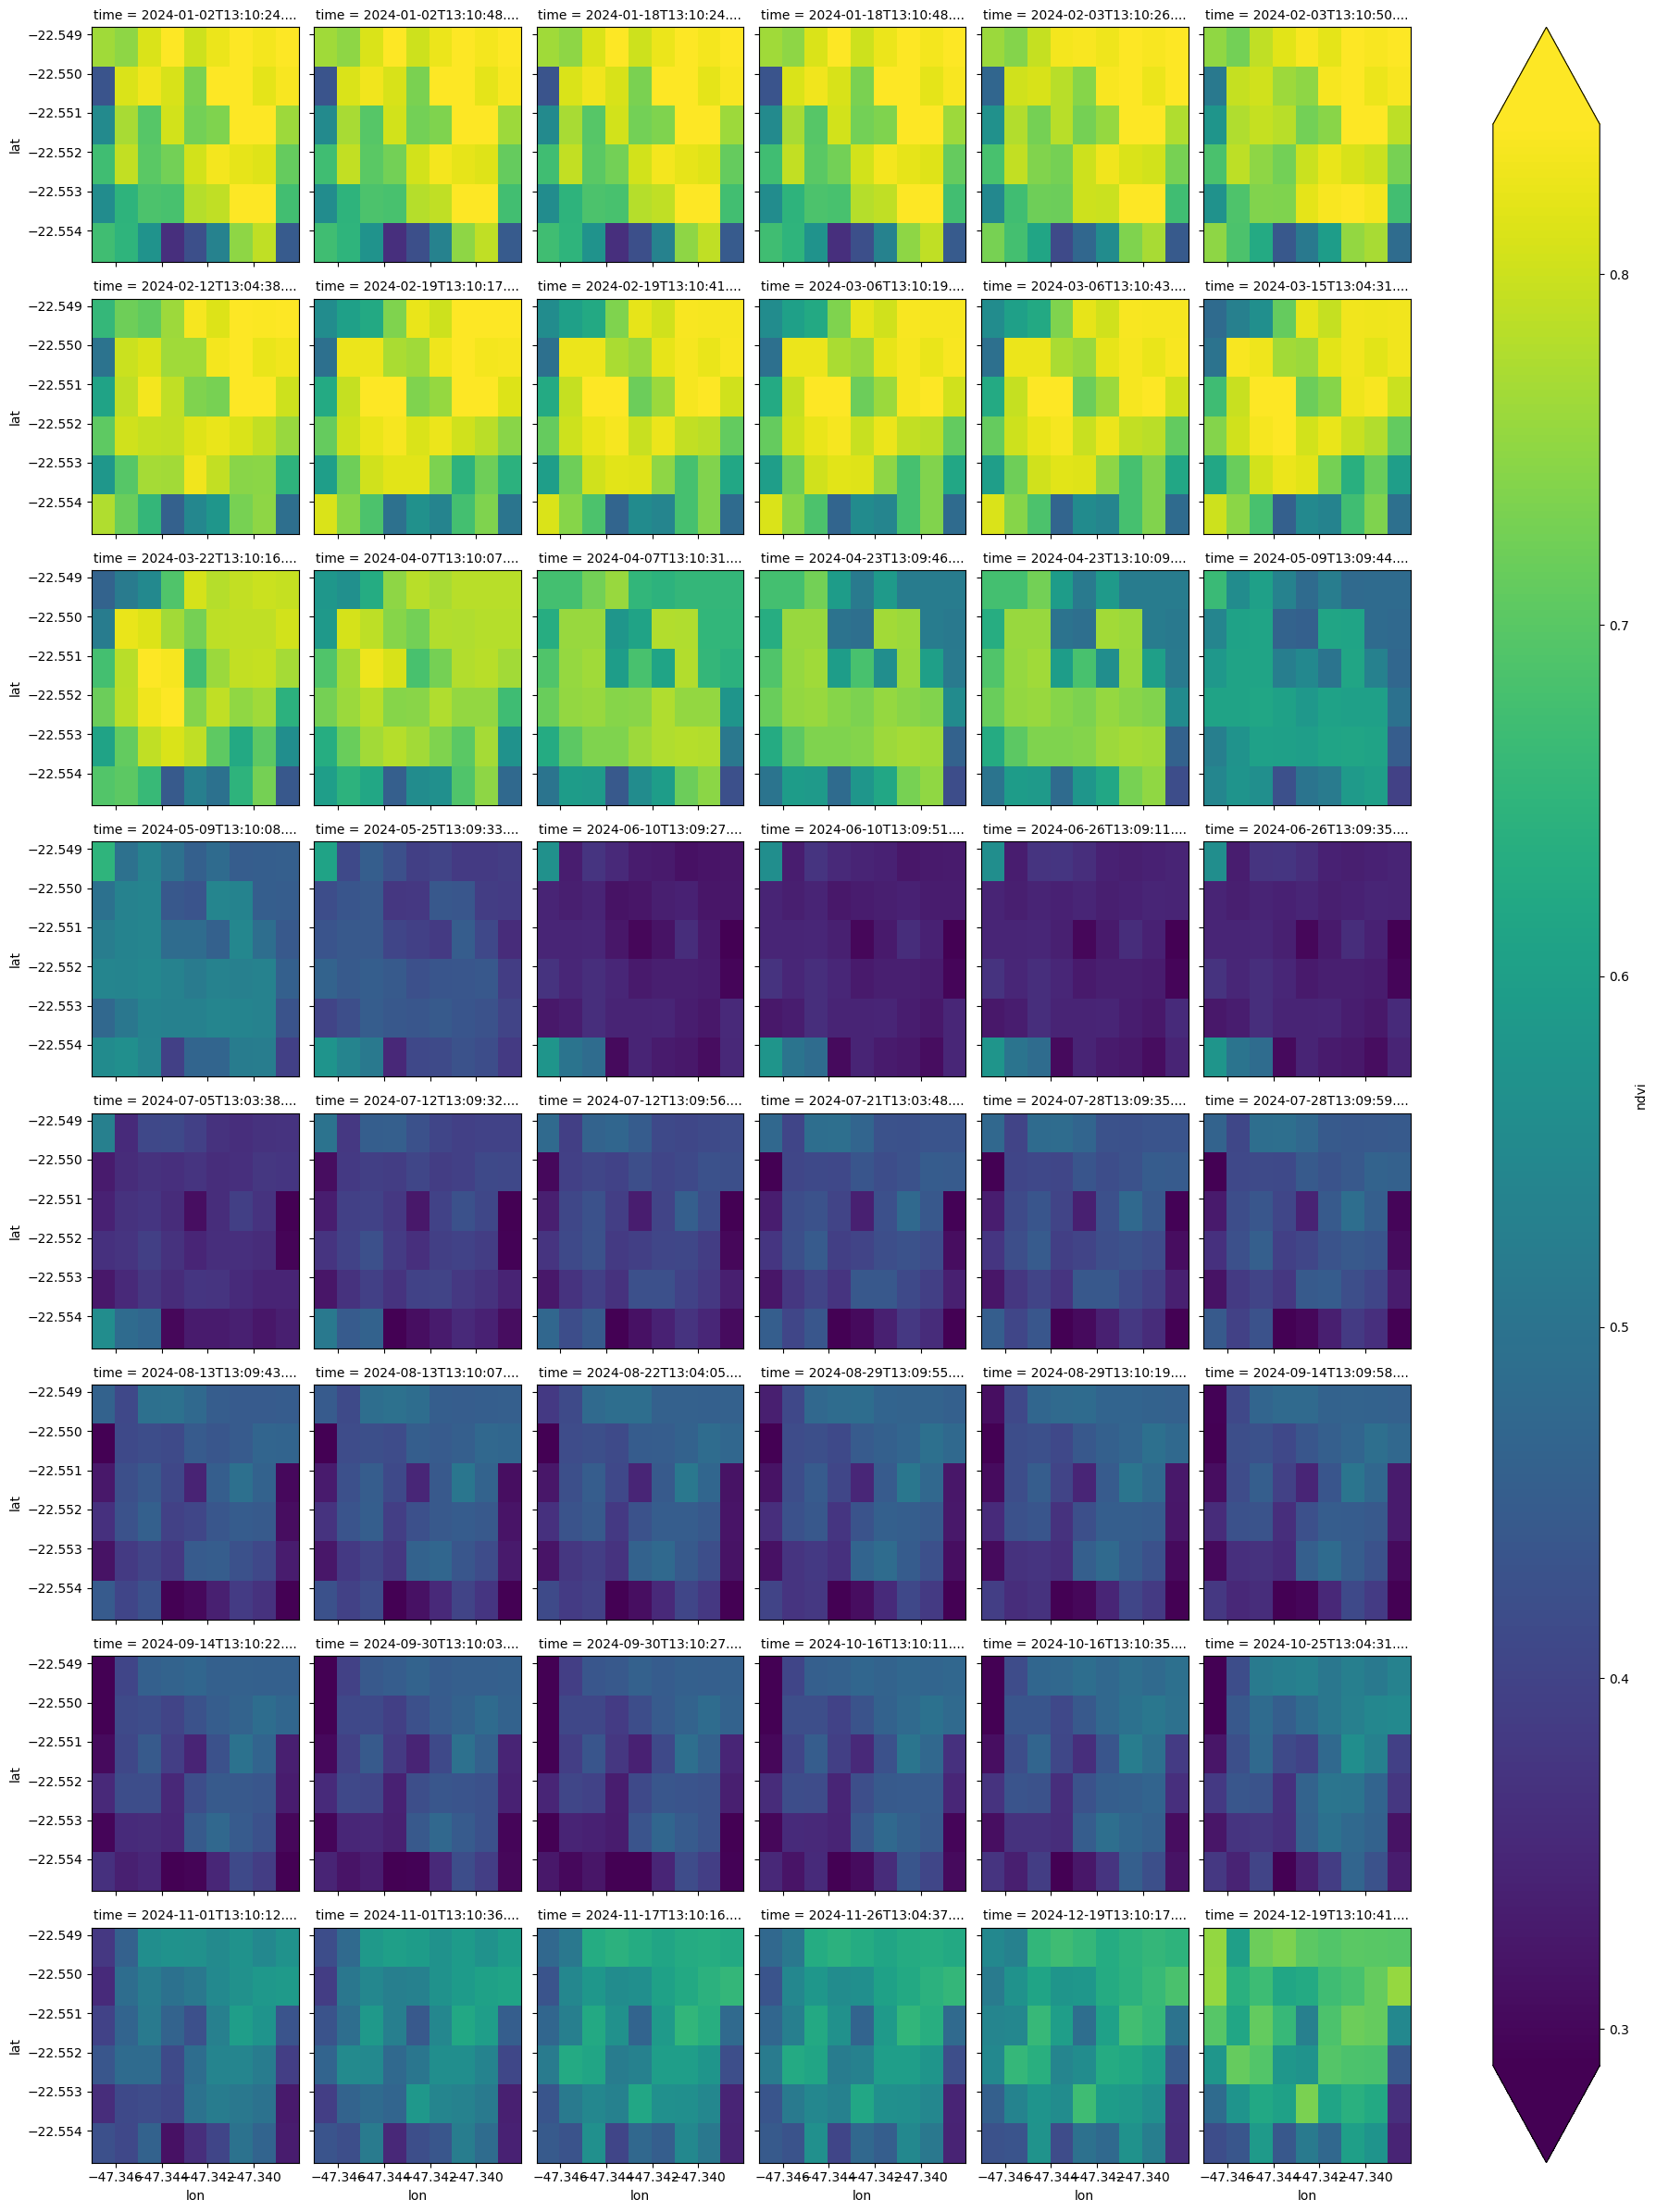

In [28]:
# plotando a figura de média móvel de 7 dias (ou 7 tempos)
ds_rol.ndvi.plot(x = 'lon',
                 y = 'lat',
                 col = 'time',
                 col_wrap = 6,
                 robust = True)

Comparação entre (a) imagens semanais e (b) média móvel de 7 tempos.


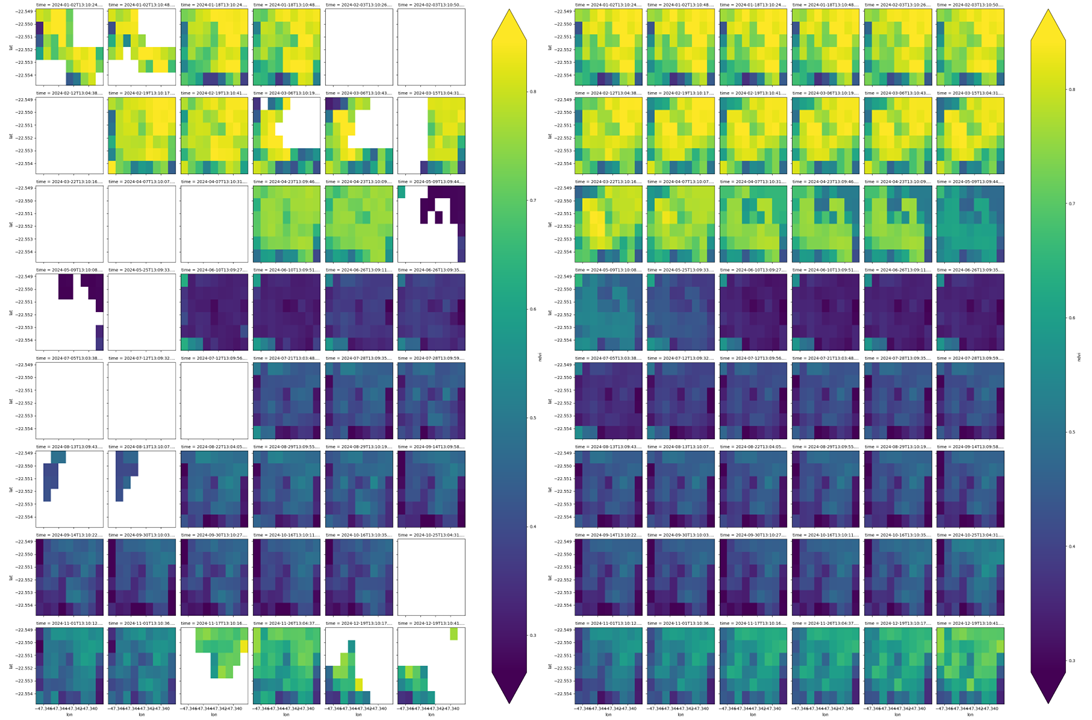